#Introduction

Jamboree Education has established itself as a premier institute for study-abroad test preparation, successfully guiding thousands of students to top global universities through their GMAT, GRE, and SAT programs. To further empower aspirants, Jamboree has introduced a data-driven feature on their website designed to estimate a candidate's probability of admission into Ivy League colleges. This initiative aims to provide students with transparent, predictive insights into their graduate application potential based on their unique academic profiles.

#Problem Statement

##Predictive Modeling:
The primary goal is to build a robust Linear Regression model that accurately predicts a student's Chance of Admit (ranging from 0 to 1) based on critical profile parameters.

##Driver Analysis:
We aim to identify which independent variables—such as GRE Scores, TOEFL Scores, University Rating, SOP/LOR strength, CGPA, and Research Experience—have the most significant impact on graduate admissions.

##Relationship Exploration:
The analysis will scrutinize the correlation and interactions between these diverse factors to understand how academic merit and research background collectively influence admission outcomes.

##Statistical Validation:
A crucial part of the problem involves rigorously testing the underlying assumptions of linear regression (including Multicollinearity, Homoscedasticity, and Normality) to ensure the model's reliability and validity.

##Strategic Recommendations:
The final objective is to derive actionable insights that allow Jamboree to refine their prediction algorithm and offer targeted counseling to students on improving their specific weak areas.

#Importing Python Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importing the Data

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/01. Data Set for Colab Notebooks/Jamboree_Admission.csv")

In [ ]:
df.head(3)

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72


#Basic Data Exploration

### 01. Identification of Variables and Data Types

In [ ]:
df.dtypes

,0
Serial No.,int64
GRE Score,int64
TOEFL Score,int64
University Rating,int64
SOP,float64
LOR,float64
CGPA,float64
Research,int64
Chance of Admit,float64


- This shows all the feature and target are nnumerical columns

In [ ]:
df.shape

(500, 9)

- Data set has 500 records
- Data set has actually 7 features (excluding Serial No.) and 1 target

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


### 02. Analysis of Basic Metrics

In [ ]:
df.describe(include='all')

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


In [ ]:
df.describe(include=np.number)

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


In [ ]:
#df.describe(include=[object])
#df.describe(include=['category'])

###03. Identifying the Missing Values

In [ ]:
missing_value = pd.DataFrame({'Missing Value': df.isnull().sum(),'Percentage':(df.isnull().sum()/len(df))*100})
missing_value.sort_values(by='Percentage',ascending=False)

,Missing Value,Percentage
Serial No.,0,0.0
GRE Score,0,0.0
TOEFL Score,0,0.0
University Rating,0,0.0
SOP,0,0.0
LOR,0,0.0
CGPA,0,0.0
Research,0,0.0
Chance of Admit,0,0.0


- Data set has no missing value

###04. Non-Graphical Analysis

In [ ]:
column = df.columns
column

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

In [ ]:
for i in column:
  if i not in ('Serial No.',"GRE Score","TOEFL Score"):
    #print(df[i].value_counts())
    print(df[i].value_counts(normalize = True)*100)


University Rating
3    32.4
2    25.2
4    21.0
5    14.6
1     6.8
Name: proportion, dtype: float64
SOP
4.0    17.8
3.5    17.6
3.0    16.0
2.5    12.8
4.5    12.6
2.0     8.6
5.0     8.4
1.5     5.0
1.0     1.2
Name: proportion, dtype: float64
LOR 
3.0    19.8
4.0    18.8
3.5    17.2
4.5    12.6
2.5    10.0
5.0    10.0
2.0     9.2
1.5     2.2
1.0     0.2
Name: proportion, dtype: float64
CGPA
8.00    1.8
8.76    1.8
8.56    1.4
8.12    1.4
8.45    1.4
       ... 
7.57    0.2
7.21    0.2
9.27    0.2
7.81    0.2
7.69    0.2
Name: proportion, Length: 184, dtype: float64
Research
1    56.0
0    44.0
Name: proportion, dtype: float64
Chance of Admit 
0.71    4.6
0.64    3.8
0.73    3.6
0.72    3.2
0.79    3.2
       ... 
0.60    0.4
0.51    0.4
0.43    0.2
0.39    0.2
0.37    0.2
Name: proportion, Length: 61, dtype: float64


- Shows the frequency of the values in % terms

In [ ]:
df.nunique()

,0
Serial No.,500
GRE Score,49
TOEFL Score,29
University Rating,5
SOP,9
LOR,9
CGPA,184
Research,2
Chance of Admit,61


- Shows unique values for each of the attributes
- Though Research is a numerical column but actually it's a categorical column

In [ ]:
df.duplicated().sum()

np.int64(0)

- Dataset has 0 duplicate records

In [ ]:
# df.drop_duplicates()

###05. Visual Analysis

In [ ]:
column = df.columns
column

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

/tmp/ipython-input-2620912674.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


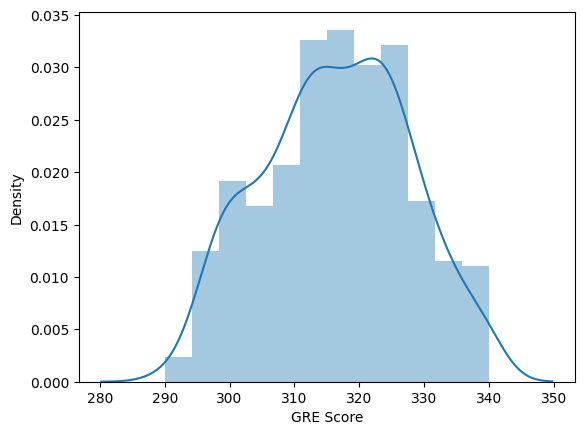

/tmp/ipython-input-2620912674.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


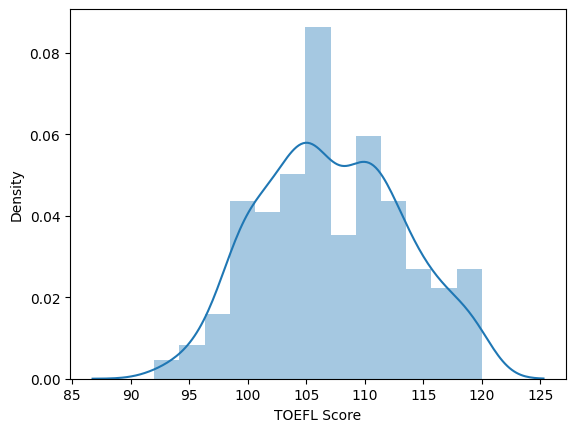

/tmp/ipython-input-2620912674.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


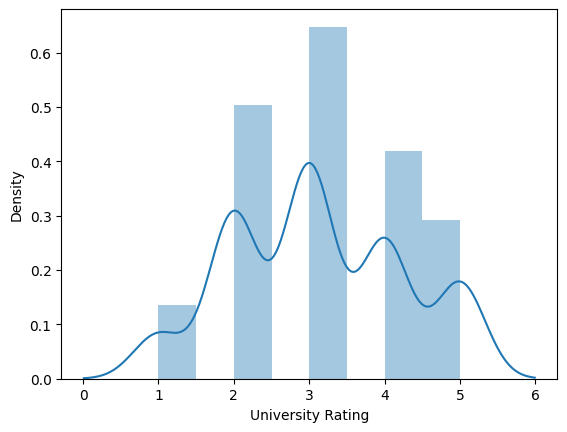

/tmp/ipython-input-2620912674.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


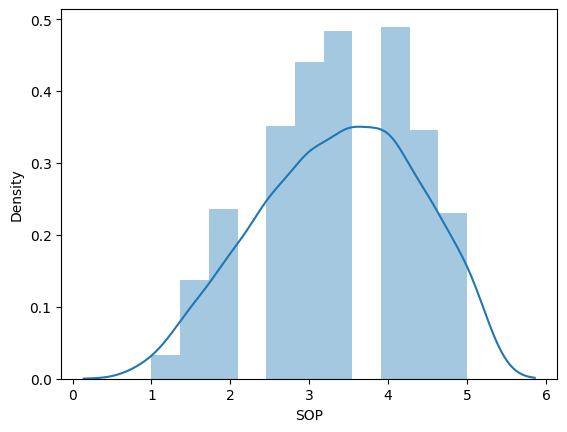

/tmp/ipython-input-2620912674.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


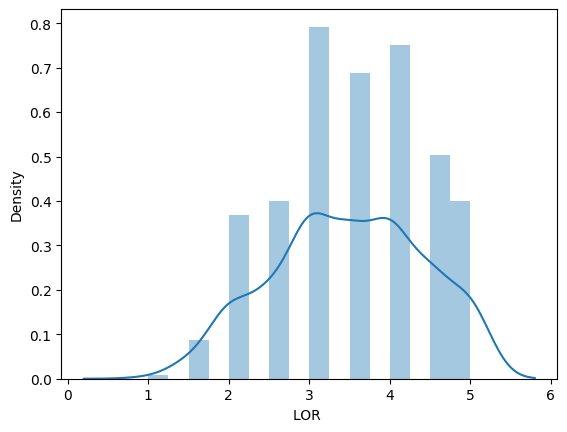

/tmp/ipython-input-2620912674.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


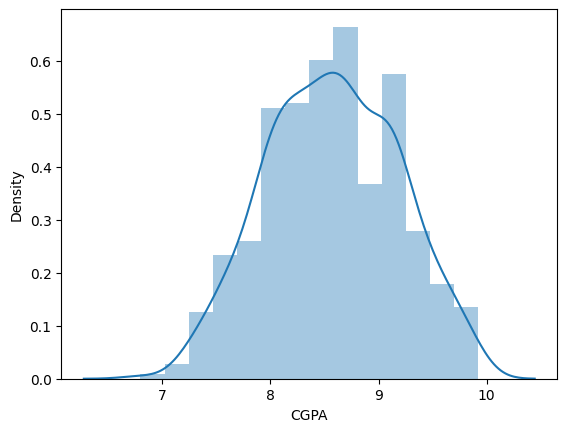

/tmp/ipython-input-2620912674.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


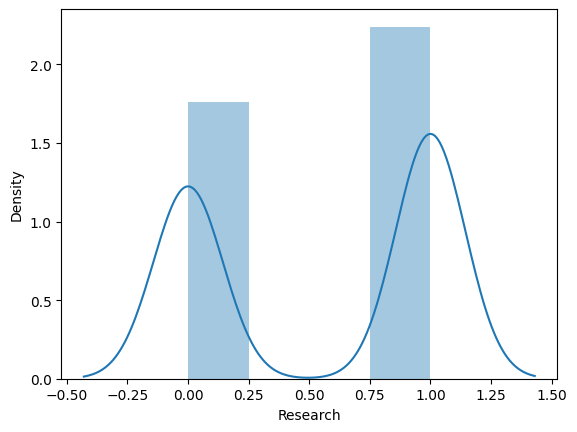

/tmp/ipython-input-2620912674.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


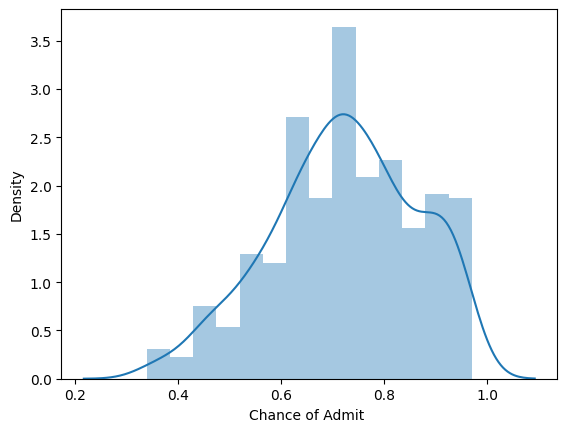

In [ ]:
#distplots for numerical columns
for i in column :
  if i not in ('Serial No.'):
    sns.distplot(df[i])
    plt.show()
    print("\n")

- Above graphs shgow the distribution of the data for each attribute

In [ ]:
column = df.columns
column

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

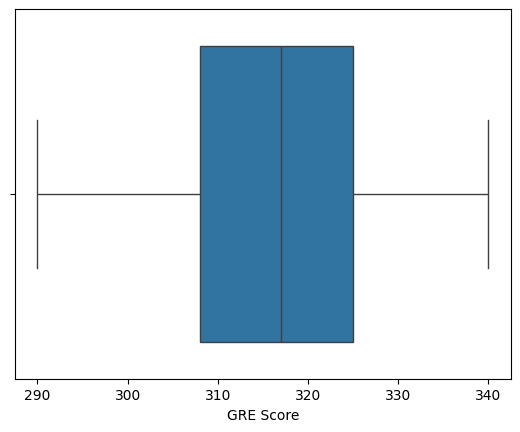

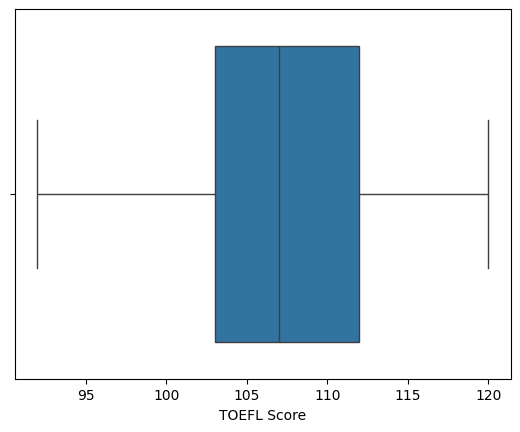

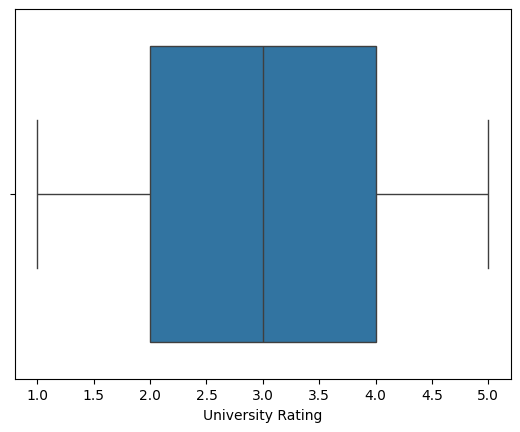

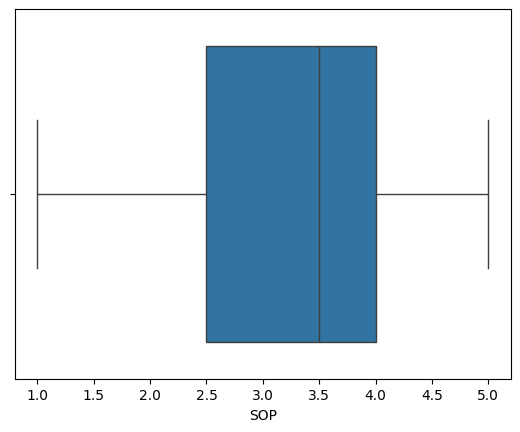

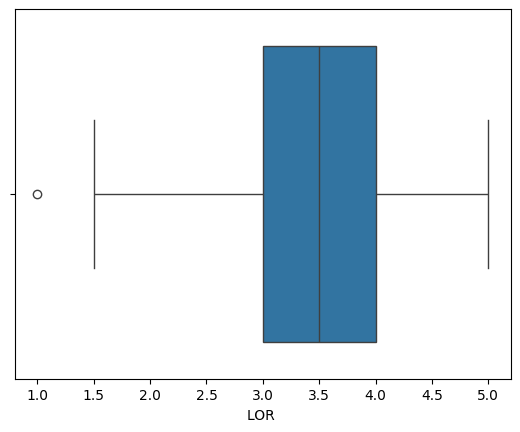

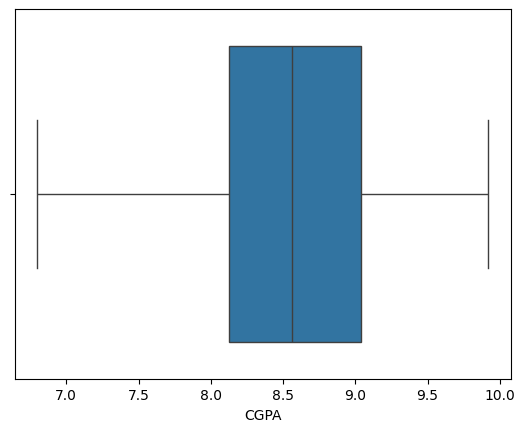

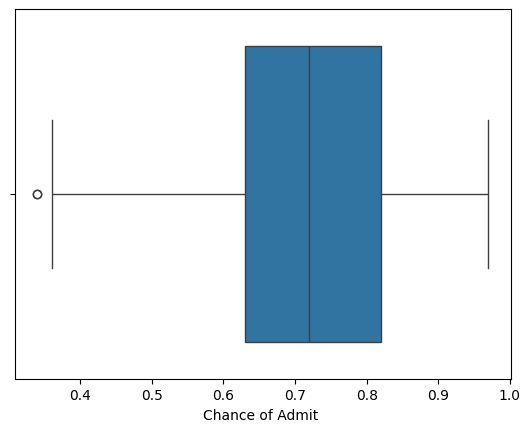

In [ ]:
#boxplot for numerical columns
j=1
for i in column :
  if i not in ('Serial No.','Research'):
    sns.boxplot(data = df, x= i)
    plt.show()
    print("\n")


- Box plot shows the distribution of the data
- Box plots show there are 3 outliers

###06. Bivariate Analysis

In [ ]:
df1 = df.drop(columns = ['Serial No.'])
df1.head(2)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76


- Dropped the Serial Number column

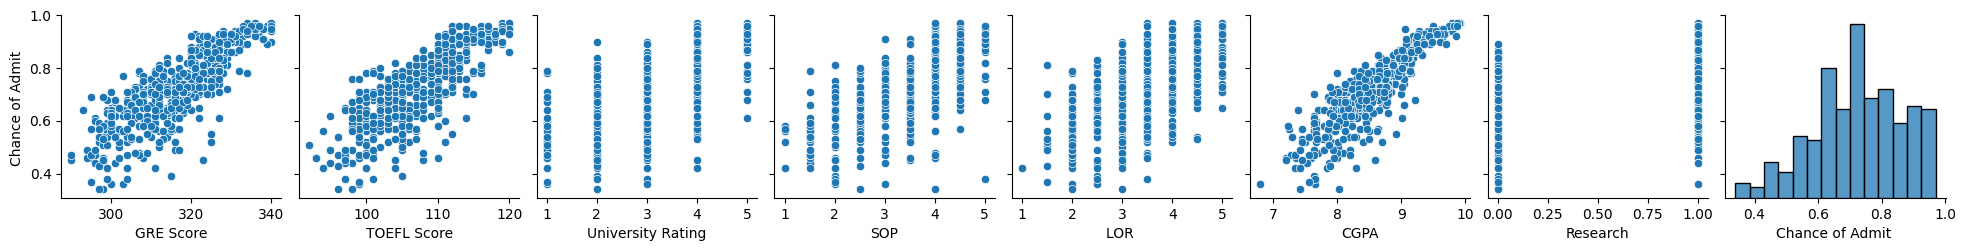

In [ ]:
sns.pairplot(data=df1, y_vars='Chance of Admit ')
plt.show()

<Axes: >

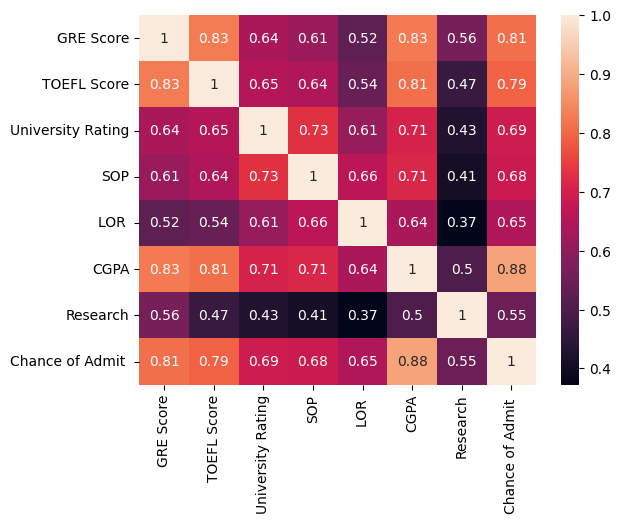

In [ ]:
#Correlation
sns.heatmap(df1.corr(),annot=True)

- Features have high Multi-Collinearity
- Features are correlated to each other

# Data Preprocessing

### Finding Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

- Data set has no duplicate value

###03. Finding the Missing Values

In [ ]:
missing_value = pd.DataFrame({'Missing Value': df.isnull().sum(),'Percentage':(df.isnull().sum()/len(df))*100})
missing_value.sort_values(by='Percentage',ascending=False)

,Missing Value,Percentage
Serial No.,0,0.0
GRE Score,0,0.0
TOEFL Score,0,0.0
University Rating,0,0.0
SOP,0,0.0
LOR,0,0.0
CGPA,0,0.0
Research,0,0.0
Chance of Admit,0,0.0


- Dataset has no missing value

###07. Outlier Detection

In [ ]:
df1.shape

(500, 8)

In [ ]:
Q1 = df1.quantile(0.25)
Q3 = df1.quantile(0.75)
IQR = Q3 - Q1

In [ ]:
df1 = df1[~((df1 < (Q1 - 1.5 * IQR)) | (df1 > (Q3 + 1.5 * IQR))).any(axis=1)]

In [ ]:
df1.shape

(497, 8)

- We removed 3 records with outliers
- df1 is free from Outliers

###08. Variable Transformation - MinMaxScaler

In [ ]:
#Splitting the data : 80% Training Data and 20% Test Data

from sklearn.model_selection import train_test_split

In [ ]:
X = df1.drop('Chance of Admit ', axis=1)
Y = df1['Chance of Admit ']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((397, 7), (397,), (100, 7), (100,))

- Here we splitted the data for training and testing
- 80% data for training
- 20% data for testing

In [ ]:
from sklearn.preprocessing import MinMaxScaler
mmscaler = MinMaxScaler()
X_train_scaled = mmscaler.fit_transform(X_train)
X_test_scaled = mmscaler.transform(X_test)

- We transformed the Features using MinMaxScaler as df1 has no outlier and all the featured are bound by some range and some of them do not follow Gaussian

In [ ]:
X_train_scaled.shape

(397, 7)

In [ ]:
X_test_scaled.shape

(100, 7)

# Model Building

###>> Building the Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
model = LinearRegression()
model.fit(X_train_scaled, Y_train)

LinearRegression()

- Linear Regression model created

###>> Display model Coefficients and Intercept

In [ ]:
print(f"Model Coefficients : {model.coef_}")
print(f"Model Intercept : {model.intercept_}")

Model Coefficients : [0.0826894  0.08383598 0.02225535 0.0145507  0.05830124 0.37518707
 0.0220937 ]
Model Intercept : 0.35322678995726076


- printing the model coefficients and intercept

###>>Model Evaluation - Train Data

In [ ]:
Y_pred = model.predict(X_train_scaled)

r2 = r2_score(Y_train, Y_pred)
mse = mean_squared_error(Y_train, Y_pred)
mae = mean_absolute_error(Y_train, Y_pred)
rmse = np.sqrt(mse)

n_train = X_train_scaled.shape[0]
p_train = X_train_scaled.shape[1]
adj_r2 = 1 - (1 - r2) * (n_train - 1) / (n_train - p_train - 1)

print(f"Linear Regression Model R-squared (Training): {r2:.4f}")
print(f"Linear Regression Model Adjusted R-squared (Training): {adj_r2:.4f}")
print(f"Linear Regression Model Mean Squared Error (Training): {mse:.4f}")
print(f"Linear Regression Model Root Mean Squared Error (Training): {rmse:.4f}")
print(f"Linear Regression Model Mean Absolute Error (Training): {mae:.4f}")

Linear Regression Model R-squared (Training): 0.8234
Linear Regression Model Adjusted R-squared (Training): 0.8202
Linear Regression Model Mean Squared Error (Training): 0.0034
Linear Regression Model Root Mean Squared Error (Training): 0.0586
Linear Regression Model Mean Absolute Error (Training): 0.0423


###>>Model Evaluation - Test Data

In [ ]:
Y_pred = model.predict(X_test_scaled)

r2 = r2_score(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mse)

n_test = X_test_scaled.shape[0]
p_test = X_test_scaled.shape[1]
adj_r2 = 1 - (1 - r2) * (n_test - 1) / (n_test - p_test - 1)

print(f"Linear Regression Model R-squared (Test): {r2:.4f}")
print(f"Linear Regression Model Adjusted R-squared (Test): {adj_r2:.4f}")
print(f"Linear Regression Model Mean Squared Error (Test): {mse:.4f}")
print(f"Linear Regression Model Root Mean Squared Error (Test): {rmse:.4f}")
print(f"Linear Regression Model Mean Absolute Error (Test): {mae:.4f}")

Linear Regression Model R-squared (Test): 0.8154
Linear Regression Model Adjusted R-squared (Test): 0.8013
Linear Regression Model Mean Squared Error (Test): 0.0034
Linear Regression Model Root Mean Squared Error (Test): 0.0582
Linear Regression Model Mean Absolute Error (Test): 0.0418


 - Model has a good fit as R2 score for training data is 0.8234 and for test data is 0.8154 --> Which is very close

###03. Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1) # You can tune alpha
ridge_model.fit(X_train_scaled, Y_train)

print(f"Ridge Model Coefficients : {ridge_model.coef_}")
print(f"Ridge Model Intercept : {ridge_model.intercept_}")

Y_pred_ridge = ridge_model.predict(X_test_scaled)

r2_ridge = r2_score(Y_test, Y_pred_ridge)
mse_ridge = mean_squared_error(Y_test, Y_pred_ridge)
mae_ridge = mean_absolute_error(Y_test, Y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)

n_test = X_test_scaled.shape[0]
p_test = X_test_scaled.shape[1]
adj_r2_ridge = 1 - (1 - r2_ridge) * (n_test - 1) / (n_test - p_test - 1)

print(f"\nRidge Model R-squared: {r2_ridge:.4f}")
print(f"Ridge Model Adjusted R-squared: {adj_r2_ridge:.4f}")
print(f"Ridge Model Mean Squared Error: {mse_ridge:.4f}")
print(f"Ridge Model Root Mean Squared Error: {rmse_ridge:.4f}")
print(f"Ridge Model Mean Absolute Error: {mae_ridge:.4f}")

Ridge Model Coefficients : [0.10072361 0.09649259 0.02902323 0.02477375 0.06546616 0.29864408
 0.02491569]
Ridge Model Intercept : 0.3652277781060907

Ridge Model R-squared: 0.8155
Ridge Model Adjusted R-squared: 0.8015
Ridge Model Mean Squared Error: 0.0034
Ridge Model Root Mean Squared Error: 0.0582
Ridge Model Mean Absolute Error: 0.0420


- Performed Ridge Regression

### Lasso Regression

In [ ]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.0001) # You can tune alpha
lasso_model.fit(X_train_scaled, Y_train)

print(f"Lasso Model Coefficients : {lasso_model.coef_}")
print(f"Lasso Model Intercept : {lasso_model.intercept_}")

Y_pred_lasso = lasso_model.predict(X_test_scaled)

r2_lasso = r2_score(Y_test, Y_pred_lasso)
mse_lasso = mean_squared_error(Y_test, Y_pred_lasso)
mae_lasso = mean_absolute_error(Y_test, Y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)

n_test = X_test_scaled.shape[0]
p_test = X_test_scaled.shape[1]
adj_r2_lasso = 1 - (1 - r2_lasso) * (n_test - 1) / (n_test - p_test - 1)

print(f"\nLasso Model R-squared: {r2_lasso:.4f}")
print(f"Lasso Model Adjusted R-squared: {adj_r2_lasso:.4f}")
print(f"Lasso Model Mean Squared Error: {mse_lasso:.4f}")
print(f"Lasso Model Root Mean Squared Error: {rmse_lasso:.4f}")
print(f"Lasso Model Mean Absolute Error: {mae_lasso:.4f}")

Lasso Model Coefficients : [0.08242723 0.08325843 0.02247506 0.01429595 0.058048   0.37303309
 0.0223611 ]
Lasso Model Intercept : 0.35493459263450894

Lasso Model R-squared: 0.8159
Lasso Model Adjusted R-squared: 0.8019
Lasso Model Mean Squared Error: 0.0034
Lasso Model Root Mean Squared Error: 0.0582
Lasso Model Mean Absolute Error: 0.0417


- Performed Lasso Regression

- We can observe that both Linear Regression and Ridge Regression have similar accuracy
- We can observe that both Linear Regression and Lasso Regression have similar accuracy


##Applying Linear Regression using OLS

In [ ]:
from statsmodels.api import OLS,add_constant

In [ ]:
X2 = add_constant(X_train_scaled)
mdl = OLS(Y_train, X2)
result = mdl.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       Chance of Admit    R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     259.1
Date:                Mon, 26 Jan 2026   Prob (F-statistic):          3.45e-142
Time:                        19:06:49   Log-Likelihood:                 563.24
No. Observations:                 397   AIC:                            -1110.
Df Residuals:                     389   BIC:                            -1079.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3532      0.010     36.027      0.000       0.334       0.373
x1             0.0827      0.027      3.009      0.003       0.029       0.137
x2             0.0838      0.027      3.067      0.002       0.030       0.138
x3             0.0223      0.017      1.337      0.182      -0.010       0.055
x4             0.0146      0.020      0.730      0.466      -0.025       0.054
x5             0.0583      0.016      3.624      0.000       0.027       0.090
x6             0.3752      0.034     11.066      0.000       0.309       0.442
x7             0.0221      0.007      2.955      0.003       0.007       0.037
==============================================================================
Omnibus:                       83.224   Durbin-Watson:                   1.915
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              184.834
Skew:                          -1.073   Prob(JB):                     7.31e-41
Kurtosis:                       5.563   Cond. No.                         23.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#Testing the Assumptions of Linear Regression

###1>> Multi-Collinearity

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
vif = pd.DataFrame()
X_tr = pd.DataFrame(X_train_scaled, columns=X.columns)
vif["Features"] = X_tr.columns
vif["VIF"] = [round(variance_inflation_factor(X_tr.values, i),2) for i in range(X_tr.shape[1])]
vif=vif.sort_values(by="VIF", ascending=False)
vif

,Features,VIF
5,CGPA,39.16
1,TOEFL Score,28.64
0,GRE Score,27.93
3,SOP,18.36
4,LOR,11.33
2,University Rating,11.15
6,Research,3.46


- Data has high multi-collinearity
- Removing multicollinearity is critical for Linear Regression because it breaks the fundamental assumption that we can isolate the effect of a single variable.

Here is the breakdown of why it is dangerous for your analysis:

1. It Destroys Interpretability (The "Ceteris Paribus" Problem)
Linear Regression coefficients attempt to answer: "If I increase GRE Score by 1 point, while holding all other variables constant, how much does admission chance go up?"

The Problem: If GRE Score and TOEFL Score are highly correlated (multicollinear), they always move together. You cannot change one without the other changing.

The Result: The model cannot mathematically distinguish which variable is responsible for the increase in admission chance. It gets confused about which feature deserves the "credit."

2. The "Teeter-Totter" Effect (Unstable Coefficients)
When two variables fight for credit, the model often assigns wild, erratic coefficients to them to make the math work.

Scenario: Without multicollinearity, GRE might have a weight of 0.5 and TOEFL 0.3.

With Multicollinearity: The model might give GRE a weight of 20.5 and TOEFL a weight of -19.7.

Why this is bad: It might look like a higher TOEFL score decreases your admission chance (negative coefficient), which completely contradicts common sense. This renders your "Actionable Insights" useless.

3. Inflated P-Values (Statistical Significance)
Multicollinearity inflates the Standard Error of your coefficients.

Because the model is uncertain about the coefficients, the "Confidence Interval" becomes very wide.

This leads to large P-values.

The Risk: You might falsely conclude that a variable (like University Rating) is not statistically significant and drop it from your recommendations, when in reality, it was significant but masked by another variable.

4. Prediction vs. Inference
If you only care about Prediction: Multicollinearity is actually not that big of a deal. The model can still predict the final Chance of Admit accurately.

If you care about Inference (Your Goal): Since your problem statement explicitly asks you to "understand what factors are important," multicollinearity is a show-stopper. You cannot identify important factors if the model can't isolate them.

- CGPA has the highest VIF i.e. 39.16, hence, we need to remove it

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df1.drop(['Chance of Admit ',"CGPA"], axis=1)
Y = df1['Chance of Admit ']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((397, 6), (397,), (100, 6), (100,))

In [ ]:
from sklearn.preprocessing import MinMaxScaler
mmscaler = MinMaxScaler()
X_train_scaled = mmscaler.fit_transform(X_train)
X_test_scaled = mmscaler.transform(X_test)

In [ ]:
vif = pd.DataFrame()
X_tr = pd.DataFrame(X_train_scaled, columns=X.columns)
vif["Features"] = X_tr.columns
vif["VIF"] = [round(variance_inflation_factor(X_tr.values, i),2) for i in range(X_tr.shape[1])]
vif=vif.sort_values(by="VIF", ascending=False)
vif

,Features,VIF
1,TOEFL Score,25.13
0,GRE Score,23.54
3,SOP,17.31
2,University Rating,11.10
4,LOR,10.25
5,Research,3.46


- Re-running VIF after removal of CGPA
- TOEFL Score has a high VIF 25.13. We need to remove this too.

In [ ]:
X = df1.drop(['Chance of Admit ', 'CGPA', 'TOEFL Score'], axis=1)
Y = df1['Chance of Admit ']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)
X_train_scaled = mmscaler.fit_transform(X_train)
X_test_scaled = mmscaler.transform(X_test)

print(f"New X_train_scaled shape: {X_train_scaled.shape}")
print(f"New X_test_scaled shape: {X_test_scaled.shape}")

New X_train_scaled shape: (397, 5)
New X_test_scaled shape: (100, 5)


In [ ]:
vif = pd.DataFrame()
X_tr = pd.DataFrame(X_train_scaled, columns=X.columns)
vif["Features"] = X_tr.columns
vif["VIF"] = [round(variance_inflation_factor(X_tr.values, i),2) for i in range(X_tr.shape[1])]
vif=vif.sort_values(by="VIF", ascending=False)
vif

,Features,VIF
2,SOP,15.89
0,GRE Score,11.57
1,University Rating,11.07
3,LOR,10.15
4,Research,3.44


- Re-running VIF after removal of TOEFL Score
- SOP has a high VIF 15.89. We need to remove this too.

In [ ]:
X = df1.drop(['Chance of Admit ', 'CGPA', 'TOEFL Score', 'SOP'], axis=1)
Y = df1['Chance of Admit ']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)
X_train_scaled = mmscaler.fit_transform(X_train)
X_test_scaled = mmscaler.transform(X_test)

print(f"New X_train_scaled shape: {X_train_scaled.shape}")
print(f"New X_test_scaled shape: {X_test_scaled.shape}")

New X_train_scaled shape: (397, 4)
New X_test_scaled shape: (100, 4)


In [ ]:
vif = pd.DataFrame()
X_tr = pd.DataFrame(X_train_scaled, columns=X.columns)
vif["Features"] = X_tr.columns
vif["VIF"] = [round(variance_inflation_factor(X_tr.values, i),2) for i in range(X_tr.shape[1])]
vif=vif.sort_values(by="VIF", ascending=False)
vif

,Features,VIF
0,GRE Score,10.21
1,University Rating,9.12
2,LOR,8.06
3,Research,3.44


- Re-running VIF after removal of SOP
- GRE Score has a high VIF 10.21. We need to remove this too.

In [ ]:
X = df1.drop(['Chance of Admit ', 'CGPA', 'GRE Score', 'SOP','TOEFL Score'], axis=1)
Y = df1['Chance of Admit ']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)
X_train_scaled = mmscaler.fit_transform(X_train)
X_test_scaled = mmscaler.transform(X_test)

print(f"New X_train_scaled shape: {X_train_scaled.shape}")
print(f"New X_test_scaled shape: {X_test_scaled.shape}")

New X_train_scaled shape: (397, 3)
New X_test_scaled shape: (100, 3)


In [ ]:
vif = pd.DataFrame()
X_tr = pd.DataFrame(X_train_scaled, columns=X.columns)
vif["Features"] = X_tr.columns
vif["VIF"] = [round(variance_inflation_factor(X_tr.values, i),2) for i in range(X_tr.shape[1])]
vif=vif.sort_values(by="VIF", ascending=False)
vif

,Features,VIF
0,University Rating,7.42
1,LOR,6.73
2,Research,2.89


- Re-running VIF after removal of GRE Score
- University Rating has a high VIF 7.42. We need to remove this too as we VIF > 5 is not acceptable

In [ ]:
X = df1.drop(['Chance of Admit ', 'CGPA', 'GRE Score', 'SOP','TOEFL Score','University Rating'], axis=1)
Y = df1['Chance of Admit ']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)
X_train_scaled = mmscaler.fit_transform(X_train)
X_test_scaled = mmscaler.transform(X_test)

print(f"New X_train_scaled shape: {X_train_scaled.shape}")
print(f"New X_test_scaled shape: {X_test_scaled.shape}")

New X_train_scaled shape: (397, 2)
New X_test_scaled shape: (100, 2)


In [ ]:
vif = pd.DataFrame()
X_tr = pd.DataFrame(X_train_scaled, columns=X.columns)
vif["Features"] = X_tr.columns
vif["VIF"] = [round(variance_inflation_factor(X_tr.values, i),2) for i in range(X_tr.shape[1])]
vif=vif.sort_values(by="VIF", ascending=False)
vif

,Features,VIF
0,LOR,2.54
1,Research,2.54


- Re-running VIF after removal of University Rating

#### Retraining the model after Mitigating Multi-Collinearity

In [ ]:
model = LinearRegression()
model.fit(X_train_scaled, Y_train)

LinearRegression()

In [ ]:
print(f"Model Coefficients : {model.coef_}")
print(f"Model Intercept : {model.intercept_}")

Model Coefficients : [0.26819661 0.10606525]
Model Intercept : 0.5115383581160002


#### Model Performance with Train Data

In [ ]:
Y_pred = model.predict(X_train_scaled)

r2 = r2_score(Y_train, Y_pred)
mse = mean_squared_error(Y_train, Y_pred)
mae = mean_absolute_error(Y_train, Y_pred)
rmse = np.sqrt(mse)

n_train = X_train_scaled.shape[0]
p_train = X_train_scaled.shape[1]
adj_r2 = 1 - (1 - r2) * (n_train - 1) / (n_train - p_train - 1)

print(f"Linear Regression Model R-squared (Training): {r2:.4f}")
print(f"Linear Regression Model Adjusted R-squared (Training): {adj_r2:.4f}")
print(f"Linear Regression Model Mean Squared Error (Training): {mse:.4f}")
print(f"Linear Regression Model Root Mean Squared Error (Training): {rmse:.4f}")
print(f"Linear Regression Model Mean Absolute Error (Training): {mae:.4f}")

Linear Regression Model R-squared (Training): 0.5426
Linear Regression Model Adjusted R-squared (Training): 0.5403
Linear Regression Model Mean Squared Error (Training): 0.0089
Linear Regression Model Root Mean Squared Error (Training): 0.0943
Linear Regression Model Mean Absolute Error (Training): 0.0745


#### Model Performance with Test Data

In [ ]:
Y_pred = model.predict(X_test_scaled)

r2 = r2_score(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mse)

n_test = X_test_scaled.shape[0]
p_test = X_test_scaled.shape[1]
adj_r2 = 1 - (1 - r2) * (n_test - 1) / (n_test - p_test - 1)

print(f"Linear Regression Model R-squared (Test): {r2:.4f}")
print(f"Linear Regression Model Adjusted R-squared (Test): {adj_r2:.4f}")
print(f"Linear Regression Model Mean Squared Error (Test): {mse:.4f}")
print(f"Linear Regression Model Root Mean Squared Error (Test): {rmse:.4f}")
print(f"Linear Regression Model Mean Absolute Error (Test): {mae:.4f}")

Linear Regression Model R-squared (Test): 0.4167
Linear Regression Model Adjusted R-squared (Test): 0.4046
Linear Regression Model Mean Squared Error (Test): 0.0107
Linear Regression Model Root Mean Squared Error (Test): 0.1035
Linear Regression Model Mean Absolute Error (Test): 0.0837


- After removal of Multi collinearity model's predictive power has reduced significantly
- Also, from real life scenario, CGPA, GRE Score and TOEFL Score are the major factors which must not be dropped
- Additionally, these features being correlated to each other is also natural as a candidate with high CGPA will score better in GRE
- Key features should not be deleted

# Recommendation : We must rely on Ridge Regression as it can handle Multi-Collinearity mathematically without requiring to delete the data

# Ridge Regression

In [ ]:
X = df1.drop('Chance of Admit ', axis=1)
Y = df1['Chance of Admit ']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((397, 7), (397,), (100, 7), (100,))

In [ ]:
from sklearn.preprocessing import MinMaxScaler
mmscaler = MinMaxScaler()
X_train_scaled = mmscaler.fit_transform(X_train)
X_test_scaled = mmscaler.transform(X_test)

In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1) # You can tune alpha
ridge_model.fit(X_train_scaled, Y_train)

print(f"Ridge Model Coefficients : {ridge_model.coef_}")
print(f"Ridge Model Intercept : {ridge_model.intercept_}")

Y_pred_ridge = ridge_model.predict(X_test_scaled)

r2_ridge = r2_score(Y_test, Y_pred_ridge)
mse_ridge = mean_squared_error(Y_test, Y_pred_ridge)
mae_ridge = mean_absolute_error(Y_test, Y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)

n_test = X_test_scaled.shape[0]
p_test = X_test_scaled.shape[1]
adj_r2_ridge = 1 - (1 - r2_ridge) * (n_test - 1) / (n_test - p_test - 1)

print(f"\nRidge Model R-squared: {r2_ridge:.4f}")
print(f"Ridge Model Adjusted R-squared: {adj_r2_ridge:.4f}")
print(f"Ridge Model Mean Squared Error: {mse_ridge:.4f}")
print(f"Ridge Model Root Mean Squared Error: {rmse_ridge:.4f}")
print(f"Ridge Model Mean Absolute Error: {mae_ridge:.4f}")

Ridge Model Coefficients : [0.10072361 0.09649259 0.02902323 0.02477375 0.06546616 0.29864408
 0.02491569]
Ridge Model Intercept : 0.3652277781060907

Ridge Model R-squared: 0.8155
Ridge Model Adjusted R-squared: 0.8015
Ridge Model Mean Squared Error: 0.0034
Ridge Model Root Mean Squared Error: 0.0582
Ridge Model Mean Absolute Error: 0.0420


##2>>Mean of Residuals

####>> Train Data

In [ ]:
Y_pred = ridge_model.predict(X_train_scaled)
residuals_train = Y_train - Y_pred
mean_residuals_train = np.mean(residuals_train)
mean_residuals_train

np.float64(-9.620068525719241e-17)

- Mean Residual for the Training Data is nearly 0

####>> Test Data

In [ ]:
Y_pred = ridge_model.predict(X_test_scaled)
residuals_test = Y_test - Y_pred
mean_residuals_test = np.mean(residuals_test)
mean_residuals_test

np.float64(0.0022891557958140863)

- Mean Residual for the Test Data is nearly 0

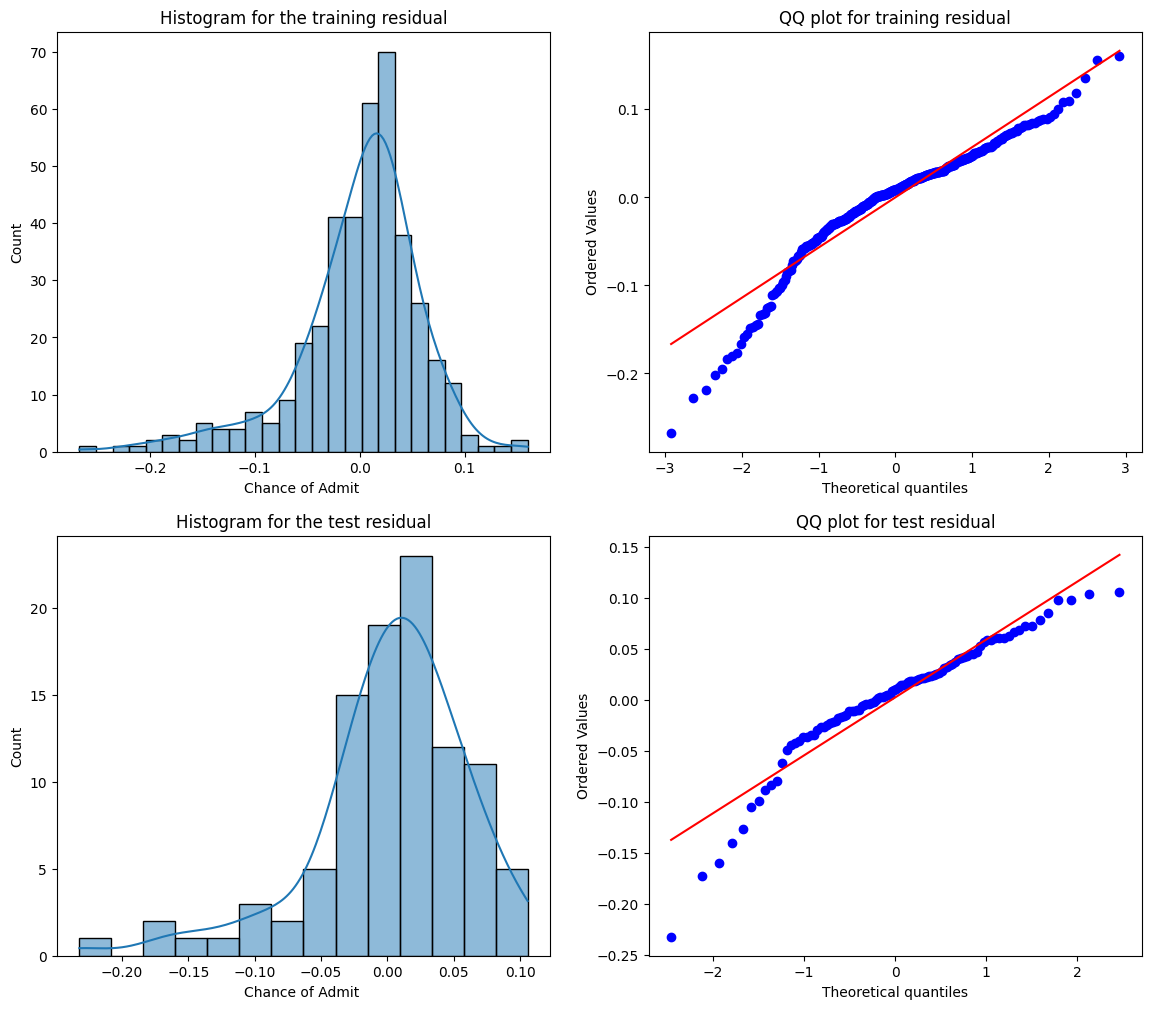

In [ ]:
import scipy.stats as stats

plt.figure(figsize=(14,12))
plt.subplot(2,2,1)
sns.histplot(residuals_train,kde = True)
plt.title('Histogram for the training residual')
plt.subplot(2,2,2)
stats.probplot(residuals_train, plot = plt)
plt.title('QQ plot for training residual')
plt.subplot(2,2,3)
sns.histplot(residuals_test,kde = True)
plt.title('Histogram for the test residual')
plt.subplot(2,2,4)
stats.probplot(residuals_test, plot = plt)
plt.title('QQ plot for test residual')
plt.show()

- Residuals approximately follows Gaussian

###3>> Linearity of Variables

Linearity of variables refers to the assumption that there is a linear relationship between the
independent variables and the dependent variable in a regression model. It means that the effect
of the independent variables on the dependent variable is constant across different levels of the
independent variables.
When we talk about “no pattern in the residual plot” in the context of linearity, we are referring to
the plot of the residuals (the differences between the observed and predicted values of the dependent
variable) against the predicted values or the independent variables.
Ideally, in a linear regression model, the residuals should be randomly scattered around zero,
without any clear patterns or trends. This indicates that the model captures the linear relationships
well and the assumption of linearity is met.
If there is a visible pattern in the residual plot, it suggests a violation of the linearity assumption.
Common patterns that indicate non-linearity include:
1. Curved or nonlinear shape: The residuals form a curved or nonlinear pattern instead of a
straight line.
2. U-shaped or inverted U-shaped pattern: The residuals show a U-shape or inverted U-shape,
indicating a nonlinear relationship.
3. Funnel-shaped pattern: The spread of residuals widens or narrows as the predicted values or
independent variables change, suggesting heteroscedasticity.
4. Clustering or uneven spread: The residuals show clustering or uneven spread across different
levels of the predicted values or independent variables.
If a pattern is observed in the residual plot, it may indicate that the linear regression model
is not appropriate, and nonlinear regression or other modeling techniques should be considered.
Additionally,transformations of variables, adding interaction terms, or using polynomial terms can
sometimes help capture nonlinear relationships and improve linearity in the residual plot.


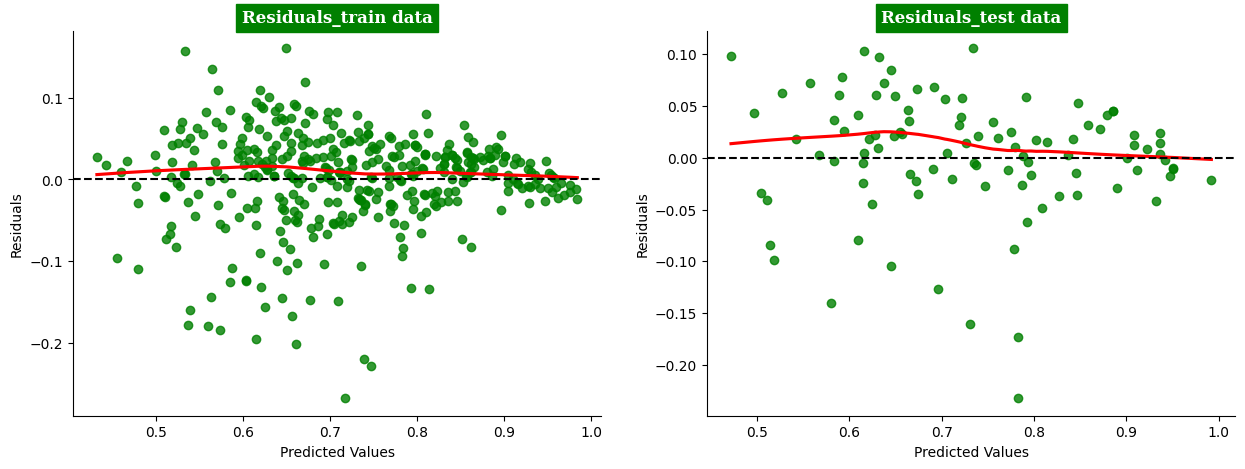

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.subplot(121)
plt.title('Residuals_train data',fontsize=12,fontfamily='serif',fontweight='bold',backgroundcolor='g',color='w')
y_pred_train = ridge_model.predict(X_train_scaled)
sns.regplot(x=y_pred_train, y=residuals_train, lowess=True, color='g',line_kws={'color': 'red'})
plt.axhline(y=0, color='k', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.subplot(122)
plt.title('Residuals_test data',fontsize=12,fontfamily='serif',fontweight='bold',backgroundcolor='g',color='w')
y_pred_test = ridge_model.predict(X_test_scaled)
sns.regplot(x=y_pred_test, y=residuals_test, lowess=True,color='g' ,line_kws={'color': 'red'})
plt.axhline(y=0, color='k', linestyle = '--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
sns.despine()
plt.show()

###4>> Checking Homoscedasticity

In [ ]:
Y_pred_train = ridge_model.predict(X_train_scaled)
residuals_train = Y_train - Y_pred_train

Y_pred_test = ridge_model.predict(X_test_scaled)
residuals_test = Y_test - Y_pred_test

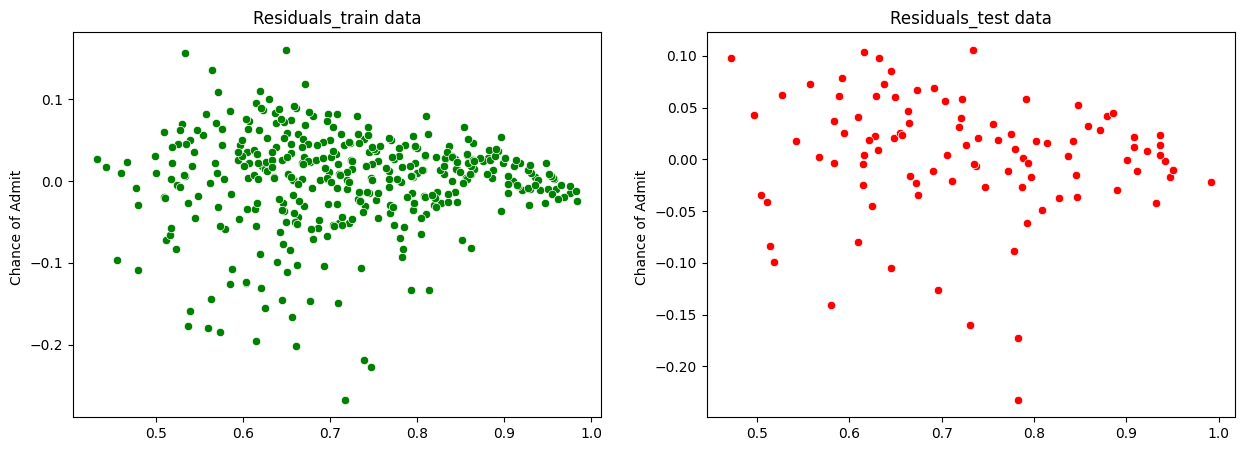

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.title('Residuals_train data')
sns.scatterplot(x=Y_pred_train, y=residuals_train, color='g')

plt.subplot(1,2,2)
plt.title('Residuals_test data')
sns.scatterplot(x=Y_pred_test, y=residuals_test, color='r')
plt.show()

In [ ]:
X_te = pd.DataFrame(X_test_scaled, columns=X.columns)

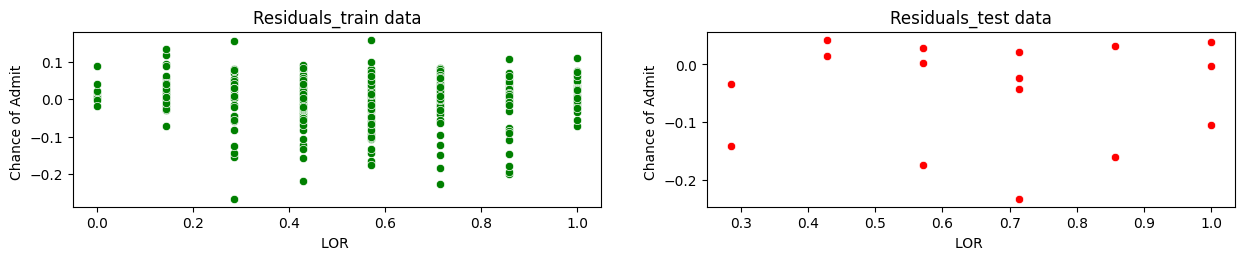

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(2,2,1)
plt.title('Residuals_train data')
sns.scatterplot(x=X_tr['LOR '], y=residuals_train, color='g')

plt.subplot(2,2,2)
plt.title('Residuals_test data')
sns.scatterplot(x=X_te['LOR '], y=residuals_test, color='r')

plt.show()

#### Performing Goldfeld Quandt Test to check Homoskedasticity

- H0 : Data is Homoskedastic
- Ha : Data is not Homoskedastic
----------
- Significance Level (alpha) : 0.05

In [ ]:
from statsmodels.compat import lzip
import statsmodels.stats.api as sms

In [ ]:
name = ['F statistic', 'p-value']
test = sms.het_goldfeldquandt(Y_train, X_train_scaled)
lzip(name, test)

[('F statistic', np.float64(0.9920876243359432)),
 ('p-value', np.float64(0.5218378831501851))]

- p-value > alpha
----------
- We fail to reject H0
- Data is Homoskedastic

###5>> Testing Normality of the Residuals

- H0 : Residuals are normally distributed
- Ha : Residuals are not normally distributed

--------

- Significance Level : 0.05

In [ ]:
from scipy.stats import shapiro
st = shapiro(residuals_train)
st.statistic

np.float64(0.9252917553345456)

In [ ]:
from scipy.stats import shapiro
st = shapiro(residuals_test)
st.statistic

np.float64(0.9183614890837279)

- We fail to reject H0 for Train and Test

-------

- Residuals are Normally Distributed

#Recommendations:

- Based on the Correlation Heatmap and Ridge Model Coefficients, here is what actually drives admissions:
    - GPA is King: CGPA has the strongest correlation with admission (0.88).    
        - Action: Jamboree's counseling should prioritize GPA enhancement or targeting universities that align strictly with a student's GPA tier. If a student has a low GPA, a high GRE score may not fully compensate
    - The "exam" Cluster: GRE and TOEFL scores are highly correlated with each other (0.83)  and with admission.
       - Action: Since these move together, students struggling with English (TOEFL) are likely struggling with the Verbal section of the GRE. Jamboree should offer bundled prep packages that address verbal reasoning holistically across both exams.
    - The Research Differentiator: Research has a moderate correlation (0.55)  but is less correlated with other academic metrics.
      - Action: For students with average GPAs/Test scores, Research experience is a unique lever to pull. Jamboree should partner with research internship programs to offer profile-building services for borderline candidates.
    - LORs and SOPs Matter Less than Grades: The correlation for LOR (0.65) and SOP (0.68) is lower than for hard metrics like GPA.
      - Action: While important, students should not neglect GRE prep to "perfect" an SOP. The hard data suggests the "numbers" (GPA/GRE) act as the primary gatekeepers.